In [2]:
import os
import requests
import zipfile
import io
import pandas as pd
from datetime import datetime, timedelta

DATA_DIR = "./data/raw"
os.makedirs(f"{DATA_DIR}/BTCUSDT", exist_ok=True)
os.makedirs(f"{DATA_DIR}/ETHUSDT", exist_ok=True)

def download_binance_data(symbol="BTCUSDT", data_type="klines/1m", start_date="2024-03-10", days=3):
    """
    Downloads Binance Historical Data Archives (klines/1m or trades)
    """
    base_url = "https://data.binance.vision/data/spot/daily"
    start_dt = datetime.strptime(start_date, "%Y-%m-%d")
    downloaded_csvs = []

    sub_folder = f"{DATA_DIR}/{symbol}/{data_type.replace('/', '_')}"
    os.makedirs(sub_folder, exist_ok=True)

    print(f"🚀 Downloading {data_type} for {symbol} ({days} Days)...")

    for i in range(days):
        date_str = (start_dt + timedelta(days=i)).strftime("%Y-%m-%d")

        if "klines" in data_type:
            url = f"{base_url}/klines/{symbol}/1m/{symbol}-1m-{date_str}.zip"
            csv_name = f"{symbol}-1m-{date_str}.csv"
        elif data_type == "trades":
            url = f"{base_url}/trades/{symbol}/{symbol}-trades-{date_str}.zip"
            csv_name = f"{symbol}-trades-{date_str}.csv"

        res = requests.get(url)
        if res.status_code == 200:
            with zipfile.ZipFile(io.BytesIO(res.content)) as z:
                z.extractall(sub_folder)
            extracted_path = os.path.join(sub_folder, csv_name)
            downloaded_csvs.append(extracted_path)
            print(f"  ✅ Extracted: {csv_name}")
        else:
            print(f"  ⚠️ Unavailable for {date_str} (HTTP {res.status_code})")

    return downloaded_csvs

# Fetch 1m Klines and Tick-Level Trades for BTC & ETH
print("--- FETCHING BTC DATA ---")
btc_kline_files = download_binance_data(symbol="BTCUSDT", data_type="klines/1m", start_date="2024-03-10", days=3)
btc_trade_files = download_binance_data(symbol="BTCUSDT", data_type="trades", start_date="2024-03-10", days=3)

print("\n--- FETCHING ETH DATA ---")
eth_kline_files = download_binance_data(symbol="ETHUSDT", data_type="klines/1m", start_date="2024-03-10", days=3)
eth_trade_files = download_binance_data(symbol="ETHUSDT", data_type="trades", start_date="2024-03-10", days=3)

--- FETCHING BTC DATA ---
🚀 Downloading klines/1m for BTCUSDT (3 Days)...
  ✅ Extracted: BTCUSDT-1m-2024-03-10.csv
  ✅ Extracted: BTCUSDT-1m-2024-03-11.csv
  ✅ Extracted: BTCUSDT-1m-2024-03-12.csv
🚀 Downloading trades for BTCUSDT (3 Days)...
  ✅ Extracted: BTCUSDT-trades-2024-03-10.csv
  ✅ Extracted: BTCUSDT-trades-2024-03-11.csv
  ✅ Extracted: BTCUSDT-trades-2024-03-12.csv

--- FETCHING ETH DATA ---
🚀 Downloading klines/1m for ETHUSDT (3 Days)...
  ✅ Extracted: ETHUSDT-1m-2024-03-10.csv
  ✅ Extracted: ETHUSDT-1m-2024-03-11.csv
  ✅ Extracted: ETHUSDT-1m-2024-03-12.csv
🚀 Downloading trades for ETHUSDT (3 Days)...
  ✅ Extracted: ETHUSDT-trades-2024-03-10.csv
  ✅ Extracted: ETHUSDT-trades-2024-03-11.csv
  ✅ Extracted: ETHUSDT-trades-2024-03-12.csv


In [3]:
# Verify Trades Data Schema (Tick level executions)
# Columns: trade_id, price, qty, quote_qty, time, is_buyer_maker, is_best_match
trade_cols = ['trade_id', 'price', 'qty', 'quote_qty', 'time', 'is_buyer_maker', 'is_best_match']
trade_sample = pd.read_csv(btc_trade_files[0], names=trade_cols)
trade_sample['datetime'] = pd.to_datetime(trade_sample['time'], unit='ms')

# Verify 1m Kline Schema
kline_cols = ['open_time', 'open', 'high', 'low', 'close', 'volume', 'close_time', 'quote_vol', 'trades_count', 'taker_buy_base_vol', 'taker_buy_quote_vol', 'ignore']
kline_sample = pd.read_csv(btc_kline_files[0], names=kline_cols)
kline_sample['datetime'] = pd.to_datetime(kline_sample['open_time'], unit='ms')

print("==========================================================")
print("📊 BTC/USDT TICK TRADES DATA (WASH TRADING & RUSH DENSITY)")
print("==========================================================")
print(trade_sample[['datetime', 'price', 'qty', 'quote_qty', 'is_buyer_maker']].head(5))

print("\n==========================================================")
print("📈 BTC/USDT 1-MINUTE OHLCV DATA")
print("==========================================================")
print(kline_sample[['datetime', 'open', 'high', 'low', 'close', 'volume', 'trades_count']].head(5))

📊 BTC/USDT TICK TRADES DATA (WASH TRADING & RUSH DENSITY)
                 datetime     price      qty   quote_qty  is_buyer_maker
0 2024-03-10 00:00:00.002  68313.28  0.00155  105.885584           False
1 2024-03-10 00:00:00.003  68313.27  0.00066   45.086758            True
2 2024-03-10 00:00:00.003  68313.27  0.00116   79.243393            True
3 2024-03-10 00:00:00.006  68313.28  0.00086   58.749421           False
4 2024-03-10 00:00:00.006  68313.28  0.00022   15.028922           False

📈 BTC/USDT 1-MINUTE OHLCV DATA
             datetime      open      high       low     close    volume  \
0 2024-03-10 00:00:00  68313.28  68340.82  68313.27  68340.82  13.17400   
1 2024-03-10 00:01:00  68340.81  68358.00  68340.81  68342.71  16.04781   
2 2024-03-10 00:02:00  68342.72  68342.72  68325.06  68325.07  14.50330   
3 2024-03-10 00:03:00  68325.07  68339.05  68317.14  68323.83  14.42956   
4 2024-03-10 00:04:00  68323.83  68323.83  68323.82  68323.82   3.87169   

   trades_count  
0  

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

print("==========================================================")
print("🔍 1. DATA COMPLETENESS & MISSING VALUES AUDIT")
print("==========================================================")
print("Kline Missing Values:\n", kline_sample.isnull().sum())
print("\nTrade Missing Values:\n", trade_sample.isnull().sum())

# Timestamp Continuity Check for 1m Klines
kline_sample['time_diff'] = kline_sample['datetime'].diff().dt.total_seconds()
expected_gap = 60 # 60 seconds for 1m klines
missing_bars = (kline_sample['time_diff'] > expected_gap).sum()

print(f"\nTime Gap Audit: Expected 60s gaps. Found {missing_bars} unexpected timestamp gaps.")

print("\n==========================================================")
print("📊 2. RAW STATISTICAL DISTRIBUTION (TICK TRADES & KLINES)")
print("==========================================================")
print("Tick Trade Quantiles (Prices & Qty):")
print(trade_sample[['price', 'qty', 'quote_qty']].describe(percentiles=[0.01, 0.5, 0.99]))

🔍 1. DATA COMPLETENESS & MISSING VALUES AUDIT
Kline Missing Values:
 open_time              0
open                   0
high                   0
low                    0
close                  0
volume                 0
close_time             0
quote_vol              0
trades_count           0
taker_buy_base_vol     0
taker_buy_quote_vol    0
ignore                 0
datetime               0
dtype: int64

Trade Missing Values:
 trade_id          0
price             0
qty               0
quote_qty         0
time              0
is_buyer_maker    0
is_best_match     0
datetime          0
dtype: int64

Time Gap Audit: Expected 60s gaps. Found 0 unexpected timestamp gaps.

📊 2. RAW STATISTICAL DISTRIBUTION (TICK TRADES & KLINES)
Tick Trade Quantiles (Prices & Qty):
              price           qty     quote_qty
count  2.139518e+06  2.139518e+06  2.139518e+06
mean   6.926568e+04  1.795015e-02  1.242947e+03
std    3.858623e+02  7.886021e-02  5.463088e+03
min    6.809475e+04  1.000000e-05  6.8

/tmp/ipykernel_696/744797716.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=trade_sample, x='aggressor_side', ax=axes[1, 0], palette='Set2')


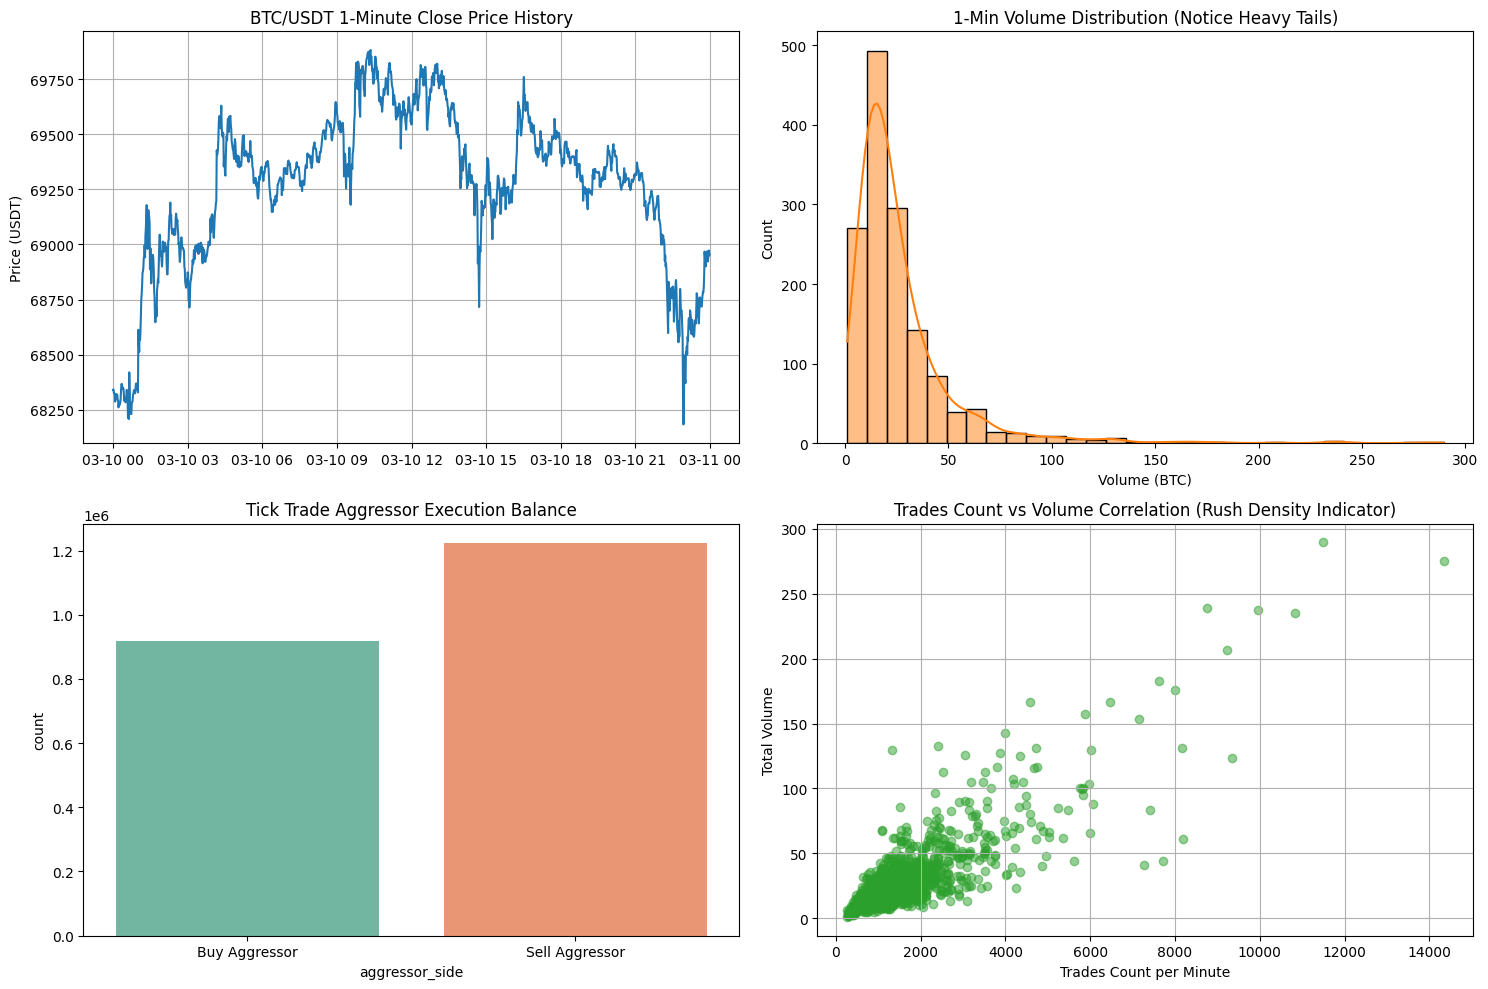

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Price Movement over Time
axes[0, 0].plot(kline_sample['datetime'], kline_sample['close'], color='tab:blue', label='BTC/USDT Close Price')
axes[0, 0].set_title('BTC/USDT 1-Minute Close Price History')
axes[0, 0].set_ylabel('Price (USDT)')
axes[0, 0].grid(True)

# 2. Volume Distribution (Heavy Tail / Outlier Check)
sns.histplot(kline_sample['volume'], kde=True, ax=axes[0, 1], color='tab:orange', bins=30)
axes[0, 1].set_title('1-Min Volume Distribution (Notice Heavy Tails)')
axes[0, 1].set_xlabel('Volume (BTC)')

# 3. Aggressor Trade Side Distribution (Buyer vs Seller)
trade_sample['aggressor_side'] = trade_sample['is_buyer_maker'].map({True: 'Sell Aggressor', False: 'Buy Aggressor'})
sns.countplot(data=trade_sample, x='aggressor_side', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Tick Trade Aggressor Execution Balance')

# 4. Trades Count vs Volume Correlation
axes[1, 1].scatter(kline_sample['trades_count'], kline_sample['volume'], alpha=0.5, color='tab:green')
axes[1, 1].set_title('Trades Count vs Volume Correlation (Rush Density Indicator)')
axes[1, 1].set_xlabel('Trades Count per Minute')
axes[1, 1].set_ylabel('Total Volume')
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

In [6]:
import numpy as np

def preprocess_and_extract_microstructure_features(trade_df, kline_df):
    """
    Preprocesses raw Binance L1 Trades & 1m Klines and generates a
    6-Dimensional Market Microstructure Feature Matrix.
    """
    print("⚙️ Executing Data Preprocessing & Microstructure Feature Extraction...")

    # 1. Classify Tick Executions into Buy & Sell Aggressor Quantities
    trade_df['buy_qty'] = np.where(~trade_df['is_buyer_maker'], trade_df['qty'], 0)
    trade_df['sell_qty'] = np.where(trade_df['is_buyer_maker'], trade_df['qty'], 0)

    # 2. Resample Tick Trades to 1-Minute Bars matching Klines
    trade_df['minute'] = trade_df['datetime'].dt.floor('min')

    tfi_grouped = trade_df.groupby('minute').agg(
        buy_vol=('buy_qty', 'sum'),
        sell_vol=('sell_qty', 'sum'),
        large_trade_count=('qty', lambda x: (x > x.quantile(0.95)).sum())
    ).reset_index()

    # Trade Flow Imbalance Ratio = (Buy - Sell) / (Buy + Sell + eps)
    tfi_grouped['trade_flow_imbalance'] = (tfi_grouped['buy_vol'] - tfi_grouped['sell_vol']) / (tfi_grouped['buy_vol'] + tfi_grouped['sell_vol'] + 1e-8)

    # 3. Merge Aggregated Trades with Kline Data
    merged_df = pd.merge(kline_df, tfi_grouped, left_on='datetime', right_on='minute', how='inner')

    # 4. Feature Transformations
    # Log Returns (Stationary Price Representation)
    merged_df['log_returns'] = np.log(merged_df['close'] / merged_df['close'].shift(1)).fillna(0)

    # High-Low Spread Ratio Proxy
    merged_df['hl_spread_ratio'] = (merged_df['high'] - merged_df['low']) / merged_df['close']

    # Rush Order Burst Density = Trades Count / Volume
    merged_df['rush_order_density'] = merged_df['trades_count'] / (merged_df['volume'] + 1e-8)

    # Volume Acceleration Index (Z-score over 15-minute rolling window)
    rolling_vol_mean = merged_df['volume'].rolling(window=15, min_periods=1).mean()
    rolling_vol_std = merged_df['volume'].rolling(window=15, min_periods=1).std().fillna(1e-5)
    merged_df['volume_acceleration'] = (merged_df['volume'] - rolling_vol_mean) / rolling_vol_std

    # Select Final Cleaned Feature Matrix
    feature_cols = [
        'datetime', 'open', 'high', 'low', 'close', 'volume', 'log_returns',
        'trade_flow_imbalance', 'hl_spread_ratio', 'rush_order_density',
        'volume_acceleration', 'large_trade_count', 'trades_count'
    ]

    processed_df = merged_df[feature_cols].copy()
    processed_df.dropna(inplace=True)

    print(f"✅ Preprocessing & Feature Extraction Complete! Final Matrix Shape: {processed_df.shape}")
    return processed_df

# Execute Pipeline for BTC Data
btc_processed_df = preprocess_and_extract_microstructure_features(trade_sample, kline_sample)

⚙️ Executing Data Preprocessing & Microstructure Feature Extraction...
✅ Preprocessing & Feature Extraction Complete! Final Matrix Shape: (1440, 13)


In [7]:
print("==========================================================")
print("📊 PROCESSED BTC/USDT 6-D MICROSTRUCTURE FEATURE MATRIX")
print("==========================================================")
print(btc_processed_df[['datetime', 'log_returns', 'trade_flow_imbalance', 'hl_spread_ratio', 'rush_order_density', 'volume_acceleration']].head(10))

print("\n==========================================================")
print("📈 STATISTICAL SUMMARY OF CLEANED FEATURES")
print("==========================================================")
print(btc_processed_df[['log_returns', 'trade_flow_imbalance', 'hl_spread_ratio', 'rush_order_density', 'volume_acceleration']].describe().T[['mean', 'std', 'min', '50%', 'max']])

📊 PROCESSED BTC/USDT 6-D MICROSTRUCTURE FEATURE MATRIX
             datetime   log_returns  trade_flow_imbalance  hl_spread_ratio  \
0 2024-03-10 00:00:00  0.000000e+00              0.491661     4.031266e-04   
1 2024-03-10 00:01:00  2.765512e-05             -0.235786     2.515265e-04   
2 2024-03-10 00:02:00 -2.581442e-04             -0.511633     2.584703e-04   
3 2024-03-10 00:03:00 -1.814870e-05             -0.273598     3.206787e-04   
4 2024-03-10 00:04:00 -1.463618e-07             -0.351219     1.463618e-07   
5 2024-03-10 00:05:00 -5.287988e-04             -0.696857     5.290850e-04   
6 2024-03-10 00:06:00  2.891757e-04             -0.119439     5.396190e-04   
7 2024-03-10 00:07:00  1.996655e-04              0.237483     3.679684e-04   
8 2024-03-10 00:08:00 -2.151628e-05             -0.441835     2.011135e-04   
9 2024-03-10 00:09:00 -9.821966e-05             -0.399484     9.822448e-05   

   rush_order_density  volume_acceleration  
0           62.016092             0.00000